In [ ]:
#import relevant libraries
import os

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from dabest._stats_tools.effsize import hedges_g

import NLCLIMB_asyn
import NLMATH_asyn

#NOTE: SUPPRESSES WARNINGS!

import warnings

warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

In [ ]:
metricframe_cache = {}

def metricframe(genotype):
    if genotype in metricframe_cache:
        return metricframe_cache[genotype].copy()

    df = pd.read_csv(openPath + genotype + ".csv")
    df = df.drop(df.columns[[0]], axis = 1)   #the compiled CSVs carry an index column
    df = NLCLIMB_asyn.generation(df, genotype)

    cy = NLMATH_asyn.calcgraph(df, "Y.*")
    cv = NLMATH_asyn.calcgraph(df, "Velocity.*")
    cb = NLMATH_asyn.calcgraph(NLMATH_asyn.boutspeed(df), "BSpeed.*")
    si = NLMATH_asyn.straightnessindexmeter(df, genotype)

    out = pd.DataFrame()
    for n in phase:
        h = cy[cy.ExperimentState == n].iloc[:, 2:].mean(axis=0)
        v = cv[cv.ExperimentState == n].iloc[:, 2:].mean(axis=0)
        b = cb[cb.ExperimentState == n].iloc[:, 2:].mean(axis=0)
        s = si[si.ExperimentState == n]["averagestraightnessindex"]

        t = pd.DataFrame({"Height": h.values, "Speed": v.values,
                          "BSpeed": b.values, "SI": s.values})
        t["fly"] = [genotype + "_" + c.rsplit("_", 1)[-1] for c in h.index]
        t["Phase"] = n
        out = pd.concat([out, t])

    out = out.reset_index(drop=True)
    metricframe_cache[genotype] = out

    return out.copy()


def arms(cross, age):
    #the pooled parental controls and the experimental, or None where there is no comparison to make.
    #Only w1118 x 95240 exists as a responder control, so most crosses pool down to the driver alone.
    if cross + "_" + age not in listofgenotypes:
        return None

    driver, responder = cross.split(" x ", 1)
    wts = [metricframe("w1118 x " + p + "_" + age) for p in [driver, responder]
           if "w1118 x " + p + "_" + age in listofgenotypes]
    if not wts:
        return None

    return pd.concat(wts).reset_index(drop=True), metricframe(cross + "_" + age)


def flies(frame, metric, n):
    return frame[frame.Phase == n].set_index("fly")[metric].dropna()


#HEATMAP 1 - the three phases against each other, paired, first phase as the baseline.
#The first phase is the baseline of its own arm, so its two columns stay blank.

def phasetable(metric):
    cols = [(a, p + "_" + g) for a in ages for g in ["Control", "Expt"] for p in phaselabels.values()]
    out = pd.DataFrame(np.nan, index = crosses, columns = pd.MultiIndex.from_tuples(cols))

    for cross in crosses:
        for age in ages:
            pair = arms(cross, age)
            if pair is None:
                continue

            for frame, group in zip(pair, ["Control", "Expt"]):
                if frame.fly.nunique() < minflies:
                    continue

                for n in phase[1:]:
                    #a fly the tracker lost in one phase cannot be paired, so it leaves both arrays
                    both = pd.DataFrame({"base": flies(frame, metric, "First phase"),
                                         "test": flies(frame, metric, n)}).dropna()
                    out.loc[cross, (age, phaselabels[n] + "_" + group)] = hedges_g(both.base.values,
                                                                                   both.test.values, "baseline")

    return out


#HEATMAP 2 - one phase, control against experimental, at each age. Unpaired: the ages are
#different flies, so there is nothing to join up.

def agetable(metric):
    cols = [(n, a) for n in phase for a in ages]
    out = pd.DataFrame(np.nan, index = crosses, columns = pd.MultiIndex.from_tuples(cols))

    for cross in crosses:
        for age in ages:
            pair = arms(cross, age)
            if pair is None:
                continue

            wt, expt = pair
            if wt.fly.nunique() < minflies or expt.fly.nunique() < minflies:
                continue

            for n in phase:
                out.loc[cross, (n, age)] = hedges_g(flies(wt, metric, n).values,
                                                    flies(expt, metric, n).values, None)

    return out

In [ ]:
#initial file processing

laptop = "C:\\Users\\lnico\\"
homecomp = "C:\\Users\\user\\"
labcomp = "C:\\Users\\User\\"

path2 = "NUS Dropbox\\acclab\\Nicole M Lee\\"
openPath = laptop + path2 + "PD\\Data Compilation\\"
savefiglocation = openPath + "images\\"

isExist = os.path.exists(savefiglocation)
if not isExist:
    os.makedirs(savefiglocation)

phase = ["First phase", "Second phase", "Third phase"]
ages = ["D10", "D20", "D30"]
metrics = ["Height", "Speed"]
rawlabels = {"Height": "Height climbed (mm)", "Speed": "Overall speed (mm/s)"}
phaselabels = {"First phase": "1st", "Second phase": "2nd", "Third phase": "3rd"}

#the rows of both heatmaps, and the smallest arm to take a g from. Edit these.
crosses = ["elav x 8146", "elav x 8147", "elav x 51375", "elav x 51376", "elav x 95240"]
minflies = 3

#the colour scale, matching the contrast_ylim for Hedges' g in 4. Dabest
vmin, vmax = -2, 2

listofgenotypes = sorted(f[:-4] for f in os.listdir(openPath) if f.endswith(".csv"))

print(len(listofgenotypes), "genotypes")

44 genotypes


C:\Users\user\NUS Dropbox\acclab\Nicole M Lee\PD\Data Compilation\images\Heatmap_phases_Height.svg


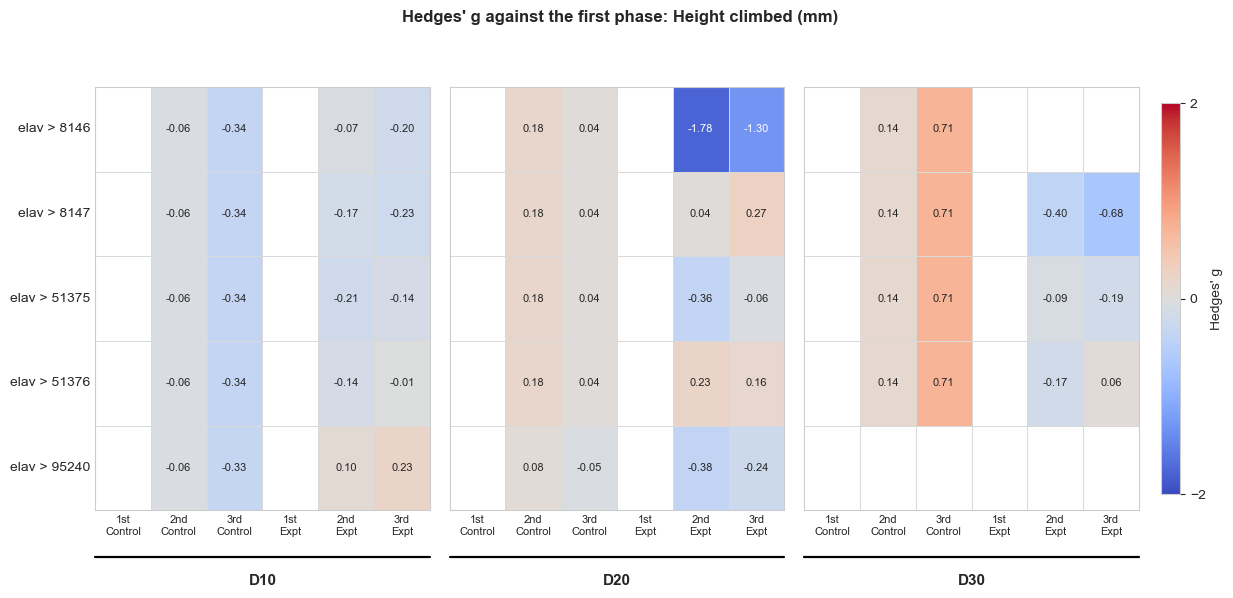

In [ ]:
#HEATMAP 1 - Height

mpl.rcParams['svg.fonttype'] = 'none'
sns.set_style("whitegrid", {'axes.grid': False})

table = phasetable("Height")

fig, axes = plt.subplots(1, len(ages), sharey = True, figsize = (14, 5.5), gridspec_kw = {"wspace": 0.06})

for ax, a in zip(axes, ages):
    block = table[a]

    sns.heatmap(block, ax = ax, cmap = "coolwarm", vmin = vmin, vmax = vmax, cbar = False,
                annot = True, fmt = ".2f", annot_kws = {"size": 8},
                linewidths = 0.5, linecolor = "#D9D9D9",
                xticklabels = [c.replace("_", "\n") for c in block.columns])

    ax.set_ylabel("")
    ax.tick_params(axis = 'both', which = 'both', length = 0)
    ax.set_xticklabels(ax.get_xticklabels(), rotation = 0, fontsize = 8)
    for s in ax.spines.values():
        s.set_visible(True)

    #the line under each block, and the age it spans
    ax.plot([0, 1], [-0.11, -0.11], transform = ax.transAxes, color = "k", lw = 1.6, clip_on = False)
    ax.text(0.5, -0.15, a, transform = ax.transAxes, ha = "center", va = "top",
            fontsize = 11, fontweight = "bold")

axes[0].set_yticklabels([c.replace(" x ", " > ") for c in table.index], rotation = 0, va = "center")

sm = plt.cm.ScalarMappable(cmap = "coolwarm", norm = mpl.colors.Normalize(vmin, vmax))
fig.colorbar(sm, ax = list(axes), fraction = 0.018, pad = 0.02, ticks = [vmin, 0, vmax]).set_label("Hedges' g")

fig.suptitle("Hedges' g against the first phase: " + rawlabels["Height"],
             fontweight = 'bold', fontsize = 12, y = 1.02)
#fig.savefig(savefiglocation + "Heatmap_phases_Height.svg", bbox_inches='tight')

print(savefiglocation + "Heatmap_phases_Height.svg")

In [ ]:
#HEATMAP 1 - Overall speed

mpl.rcParams['svg.fonttype'] = 'none'
sns.set_style("whitegrid", {'axes.grid': False})

table = phasetable("Speed")

fig, axes = plt.subplots(1, len(ages), sharey = True, figsize = (14, 5.5), gridspec_kw = {"wspace": 0.06})

for ax, a in zip(axes, ages):
    block = table[a]

    sns.heatmap(block, ax = ax, cmap = "coolwarm", vmin = vmin, vmax = vmax, cbar = False,
                annot = True, fmt = ".2f", annot_kws = {"size": 8},
                linewidths = 0.5, linecolor = "#D9D9D9",
                xticklabels = [c.replace("_", "\n") for c in block.columns])

    ax.set_ylabel("")
    ax.tick_params(axis = 'both', which = 'both', length = 0)
    ax.set_xticklabels(ax.get_xticklabels(), rotation = 0, fontsize = 8)
    for s in ax.spines.values():
        s.set_visible(True)

    #the line under each block, and the age it spans
    ax.plot([0, 1], [-0.11, -0.11], transform = ax.transAxes, color = "k", lw = 1.6, clip_on = False)
    ax.text(0.5, -0.15, a, transform = ax.transAxes, ha = "center", va = "top",
            fontsize = 11, fontweight = "bold")

axes[0].set_yticklabels([c.replace(" x ", " > ") for c in table.index], rotation = 0, va = "center")

sm = plt.cm.ScalarMappable(cmap = "coolwarm", norm = mpl.colors.Normalize(vmin, vmax))
fig.colorbar(sm, ax = list(axes), fraction = 0.018, pad = 0.02, ticks = [vmin, 0, vmax]).set_label("Hedges' g")

fig.suptitle("Hedges' g against the first phase: " + rawlabels["Speed"],
             fontweight = 'bold', fontsize = 12, y = 1.02)
#fig.savefig(savefiglocation + "Heatmap_phases_Speed.svg", bbox_inches='tight')

print(savefiglocation + "Heatmap_phases_Speed.svg")

In [ ]:
#HEATMAP 2 - Height

mpl.rcParams['svg.fonttype'] = 'none'
sns.set_style("whitegrid", {'axes.grid': False})

table = agetable("Height")

fig, axes = plt.subplots(1, len(phase), sharey = True, figsize = (9, 5.5), gridspec_kw = {"wspace": 0.06})

for ax, n in zip(axes, phase):
    block = table[n]

    sns.heatmap(block, ax = ax, cmap = "coolwarm", vmin = vmin, vmax = vmax, cbar = False,
                annot = True, fmt = ".2f", annot_kws = {"size": 8},
                linewidths = 0.5, linecolor = "#D9D9D9")

    ax.set_ylabel("")
    ax.tick_params(axis = 'both', which = 'both', length = 0)
    ax.set_xticklabels(ax.get_xticklabels(), rotation = 0, fontsize = 8)
    for s in ax.spines.values():
        s.set_visible(True)

    #the line under each block, and the phase it spans
    ax.plot([0, 1], [-0.11, -0.11], transform = ax.transAxes, color = "k", lw = 1.6, clip_on = False)
    ax.text(0.5, -0.15, phaselabels[n] + " phase", transform = ax.transAxes, ha = "center", va = "top",
            fontsize = 11, fontweight = "bold")

axes[0].set_yticklabels([c.replace(" x ", " > ") for c in table.index], rotation = 0, va = "center")

sm = plt.cm.ScalarMappable(cmap = "coolwarm", norm = mpl.colors.Normalize(vmin, vmax))
fig.colorbar(sm, ax = list(axes), fraction = 0.018, pad = 0.02, ticks = [vmin, 0, vmax]).set_label("Hedges' g")

fig.suptitle("Hedges' g against the control: " + rawlabels["Height"],
             fontweight = 'bold', fontsize = 12, y = 1.02)
#fig.savefig(savefiglocation + "Heatmap_ages_Height.svg", bbox_inches='tight')

print(savefiglocation + "Heatmap_ages_Height.svg")

In [ ]:
#HEATMAP 2 - Overall speed

mpl.rcParams['svg.fonttype'] = 'none'
sns.set_style("whitegrid", {'axes.grid': False})

table = agetable("Speed")

fig, axes = plt.subplots(1, len(phase), sharey = True, figsize = (9, 5.5), gridspec_kw = {"wspace": 0.06})

for ax, n in zip(axes, phase):
    block = table[n]

    sns.heatmap(block, ax = ax, cmap = "coolwarm", vmin = vmin, vmax = vmax, cbar = False,
                annot = True, fmt = ".2f", annot_kws = {"size": 8},
                linewidths = 0.5, linecolor = "#D9D9D9")

    ax.set_ylabel("")
    ax.tick_params(axis = 'both', which = 'both', length = 0)
    ax.set_xticklabels(ax.get_xticklabels(), rotation = 0, fontsize = 8)
    for s in ax.spines.values():
        s.set_visible(True)

    #the line under each block, and the phase it spans
    ax.plot([0, 1], [-0.11, -0.11], transform = ax.transAxes, color = "k", lw = 1.6, clip_on = False)
    ax.text(0.5, -0.15, phaselabels[n] + " phase", transform = ax.transAxes, ha = "center", va = "top",
            fontsize = 11, fontweight = "bold")

axes[0].set_yticklabels([c.replace(" x ", " > ") for c in table.index], rotation = 0, va = "center")

sm = plt.cm.ScalarMappable(cmap = "coolwarm", norm = mpl.colors.Normalize(vmin, vmax))
fig.colorbar(sm, ax = list(axes), fraction = 0.018, pad = 0.02, ticks = [vmin, 0, vmax]).set_label("Hedges' g")

fig.suptitle("Hedges' g against the control: " + rawlabels["Speed"],
             fontweight = 'bold', fontsize = 12, y = 1.02)
#fig.savefig(savefiglocation + "Heatmap_ages_Speed.svg", bbox_inches='tight')

print(savefiglocation + "Heatmap_ages_Speed.svg")